# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Loading and Saving
from moments.saving import get_experiment_paths

data_dir, plots_dir = get_experiment_paths(__vsc_ipynb_file__)

# Load data

In [2]:
ent = np.load(data_dir / "concurrence.npz")
ent_max = ent["max"]
ent_min = ent["min"]

## Moment space discretization

In [3]:
D = 200
Dx, Dz = D + 1, int(np.sqrt(3) * D) + 1

x = np.linspace(0, 1, Dx)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

# Ploting

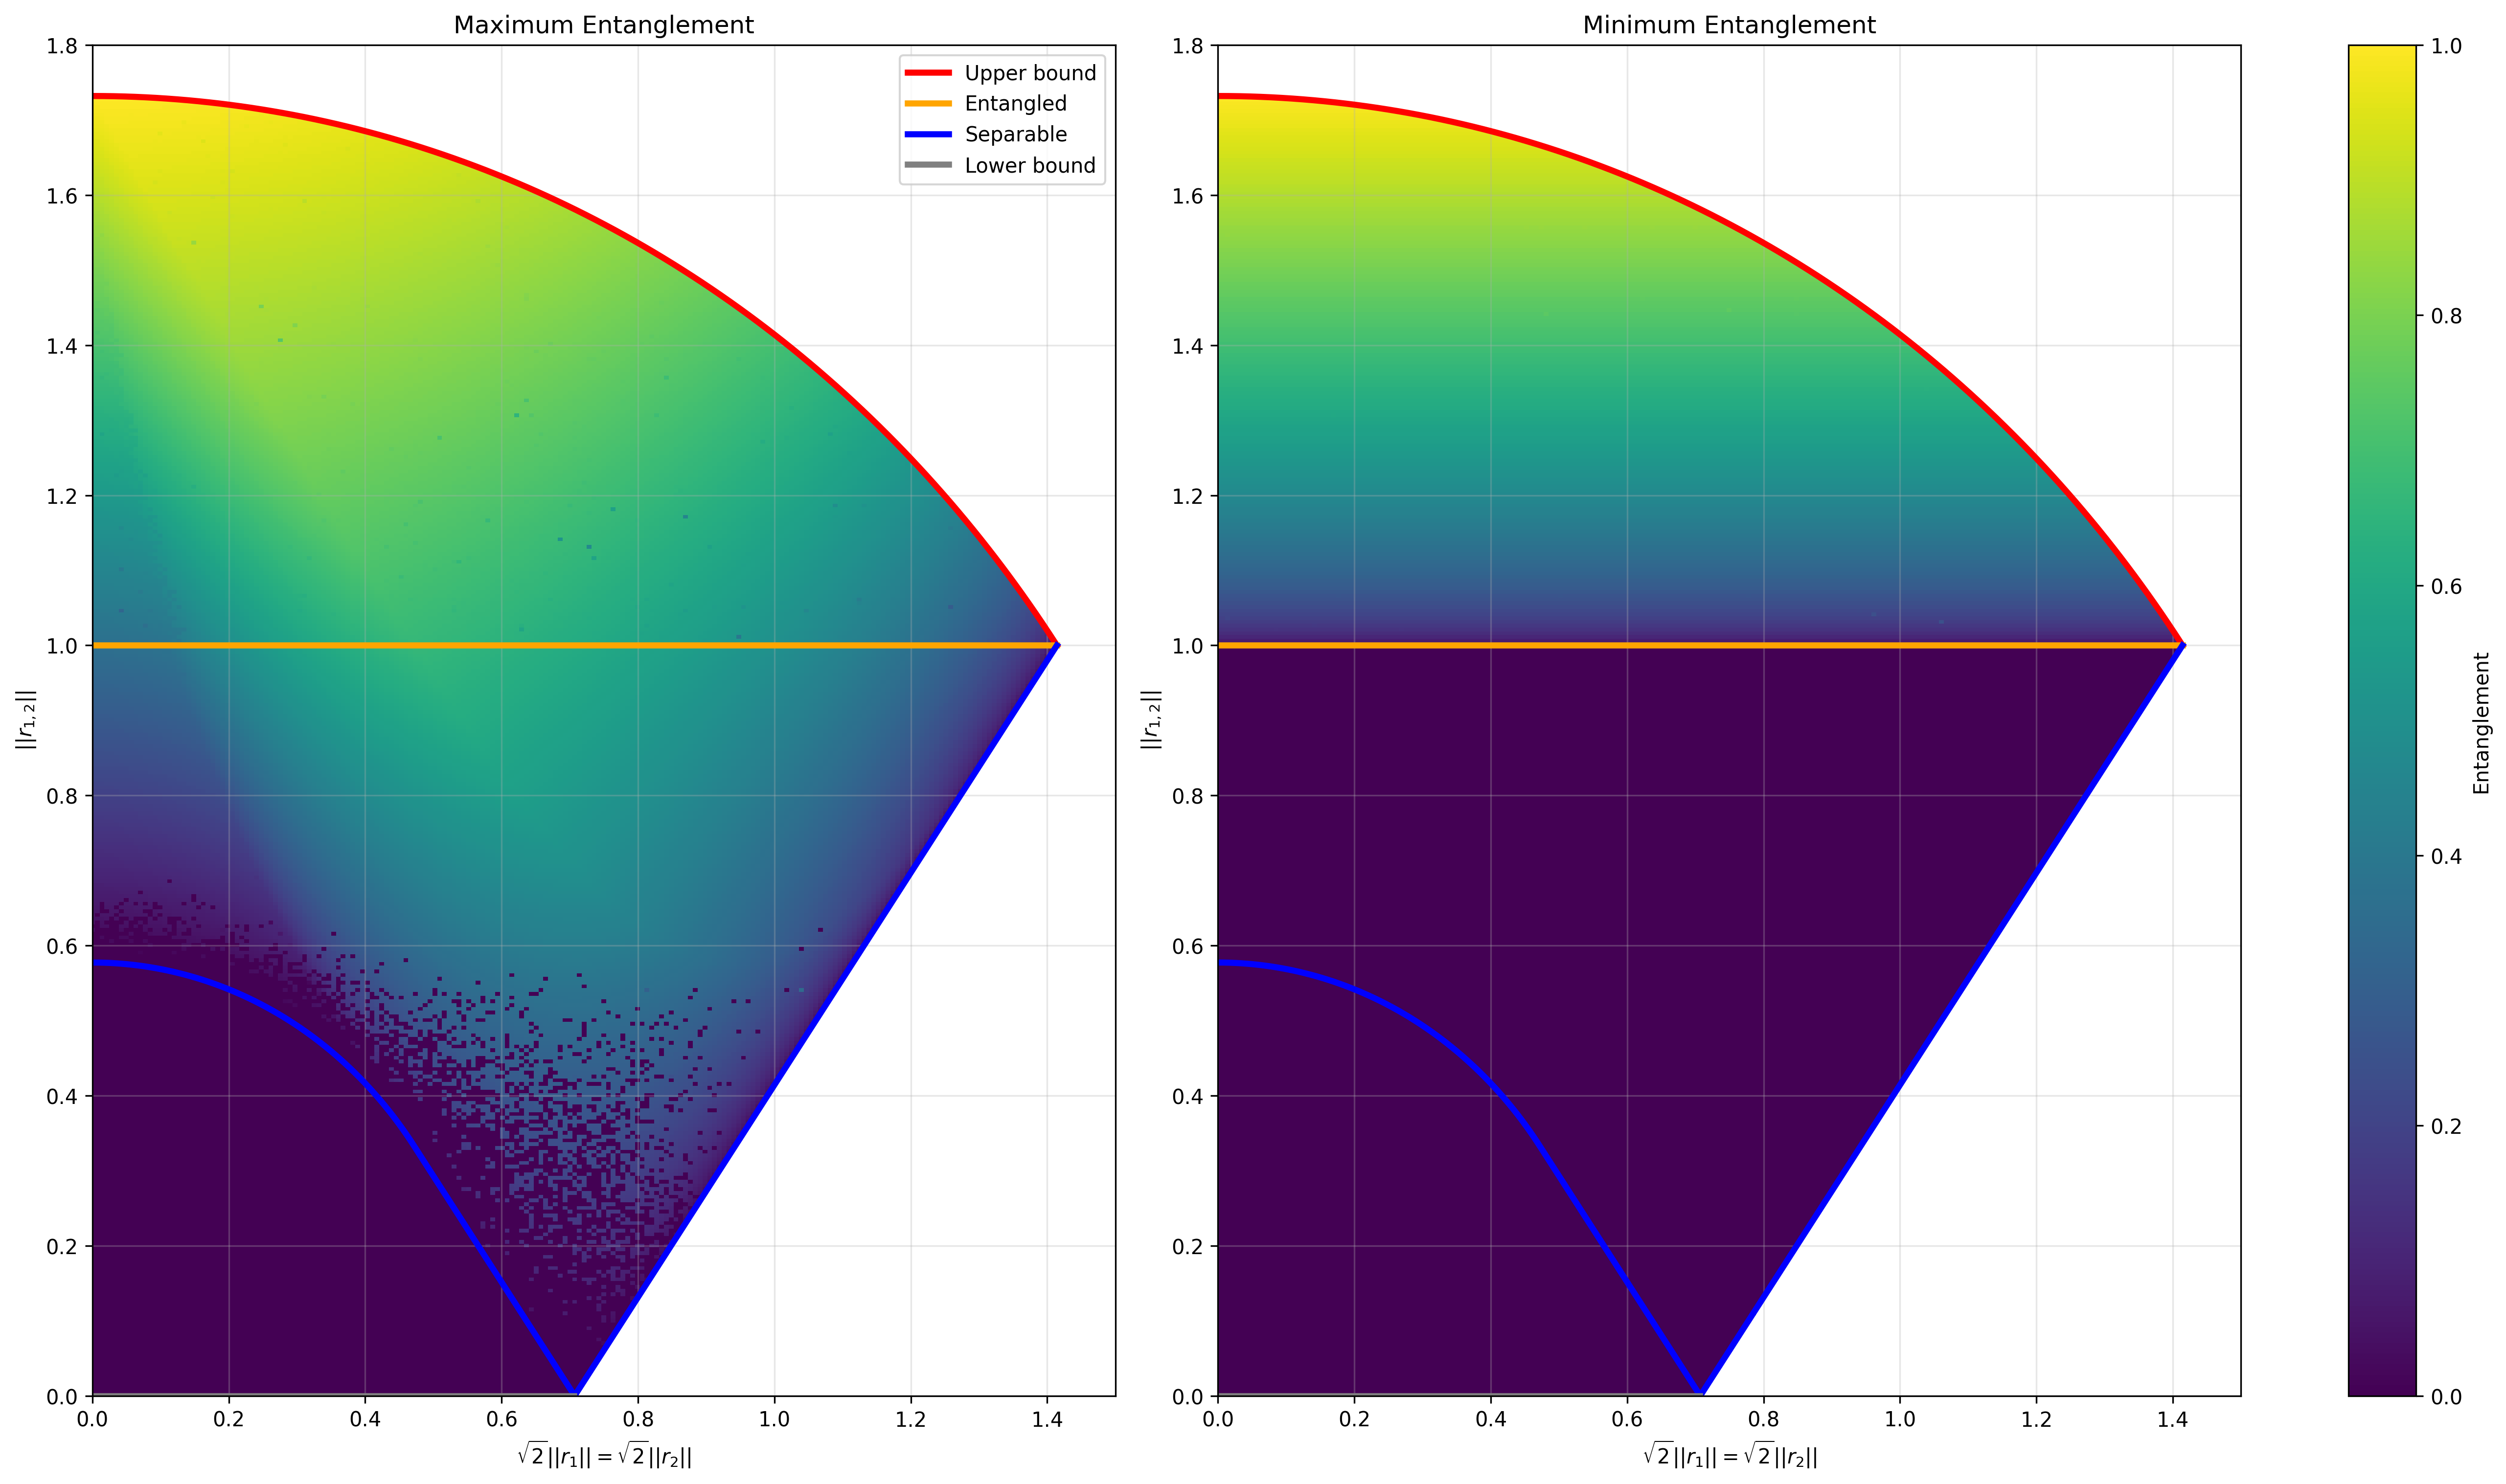

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(17, 10), constrained_layout=True, dpi=300)

mesh0 = ax[0].pcolormesh(np.sqrt(2) * X, Z, ent_max, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh1 = ax[1].pcolormesh(np.sqrt(2) * X, Z, ent_min, shading='auto', cmap='viridis', vmin=0, vmax=1)

cbar = fig.colorbar(mesh1, ax=ax.ravel().tolist(), label='Entanglement', 
                    pad=0.05, aspect=20, shrink=1)

cbar.set_ticks(list(np.linspace(0, 1, 6)))

ax[0].set(xlabel = r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
xlim = (0, 1.5), ylim = (0, 1.8), title = "Maximum Entanglement")
ax[1].set(xlabel = r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
xlim = (0, 1.5), ylim = (0, 1.8), title = "Minimum Entanglement")

t = np.linspace(0, np.sqrt(2), 1000)
z_upper = np.sqrt(3 - t**2)
z_sep = np.piecewise(t, [t <= np.sqrt(2)/3, (t > np.sqrt(2)/3) & (t <= np.sqrt(2)/2), t > np.sqrt(2)/2],
                     [lambda t: np.sqrt(1/3 - t**2), lambda t: 1 - np.sqrt(2) * t, lambda t: np.sqrt(2) * t - 1])
z_ent = np.ones_like(t)
z_lower = np.where(t < np.sqrt(2)/2, 0, np.nan)

ax[0].plot(t, z_upper, 'red', linewidth=3, label='Upper bound')
ax[0].plot(t, z_ent, 'orange', linewidth=3, label='Entangled')
ax[0].plot(t, z_sep, 'blue', linewidth=3, label='Separable')
ax[0].plot(t, z_lower, 'grey', linewidth=3, label='Lower bound')

ax[1].plot(t, z_upper, 'red', linewidth=3, label='Upper bound')
ax[1].plot(t, z_ent, 'orange', linewidth=3, label='Entangled')
ax[1].plot(t, z_sep, 'blue', linewidth=3, label='Separable')
ax[1].plot(t, z_lower, 'grey', linewidth=3, label='Lower bound')

ax[0].legend(loc='upper right')
ax[0].grid(True, alpha=0.3)
ax[1].grid(True, alpha=0.3)

plt.show()

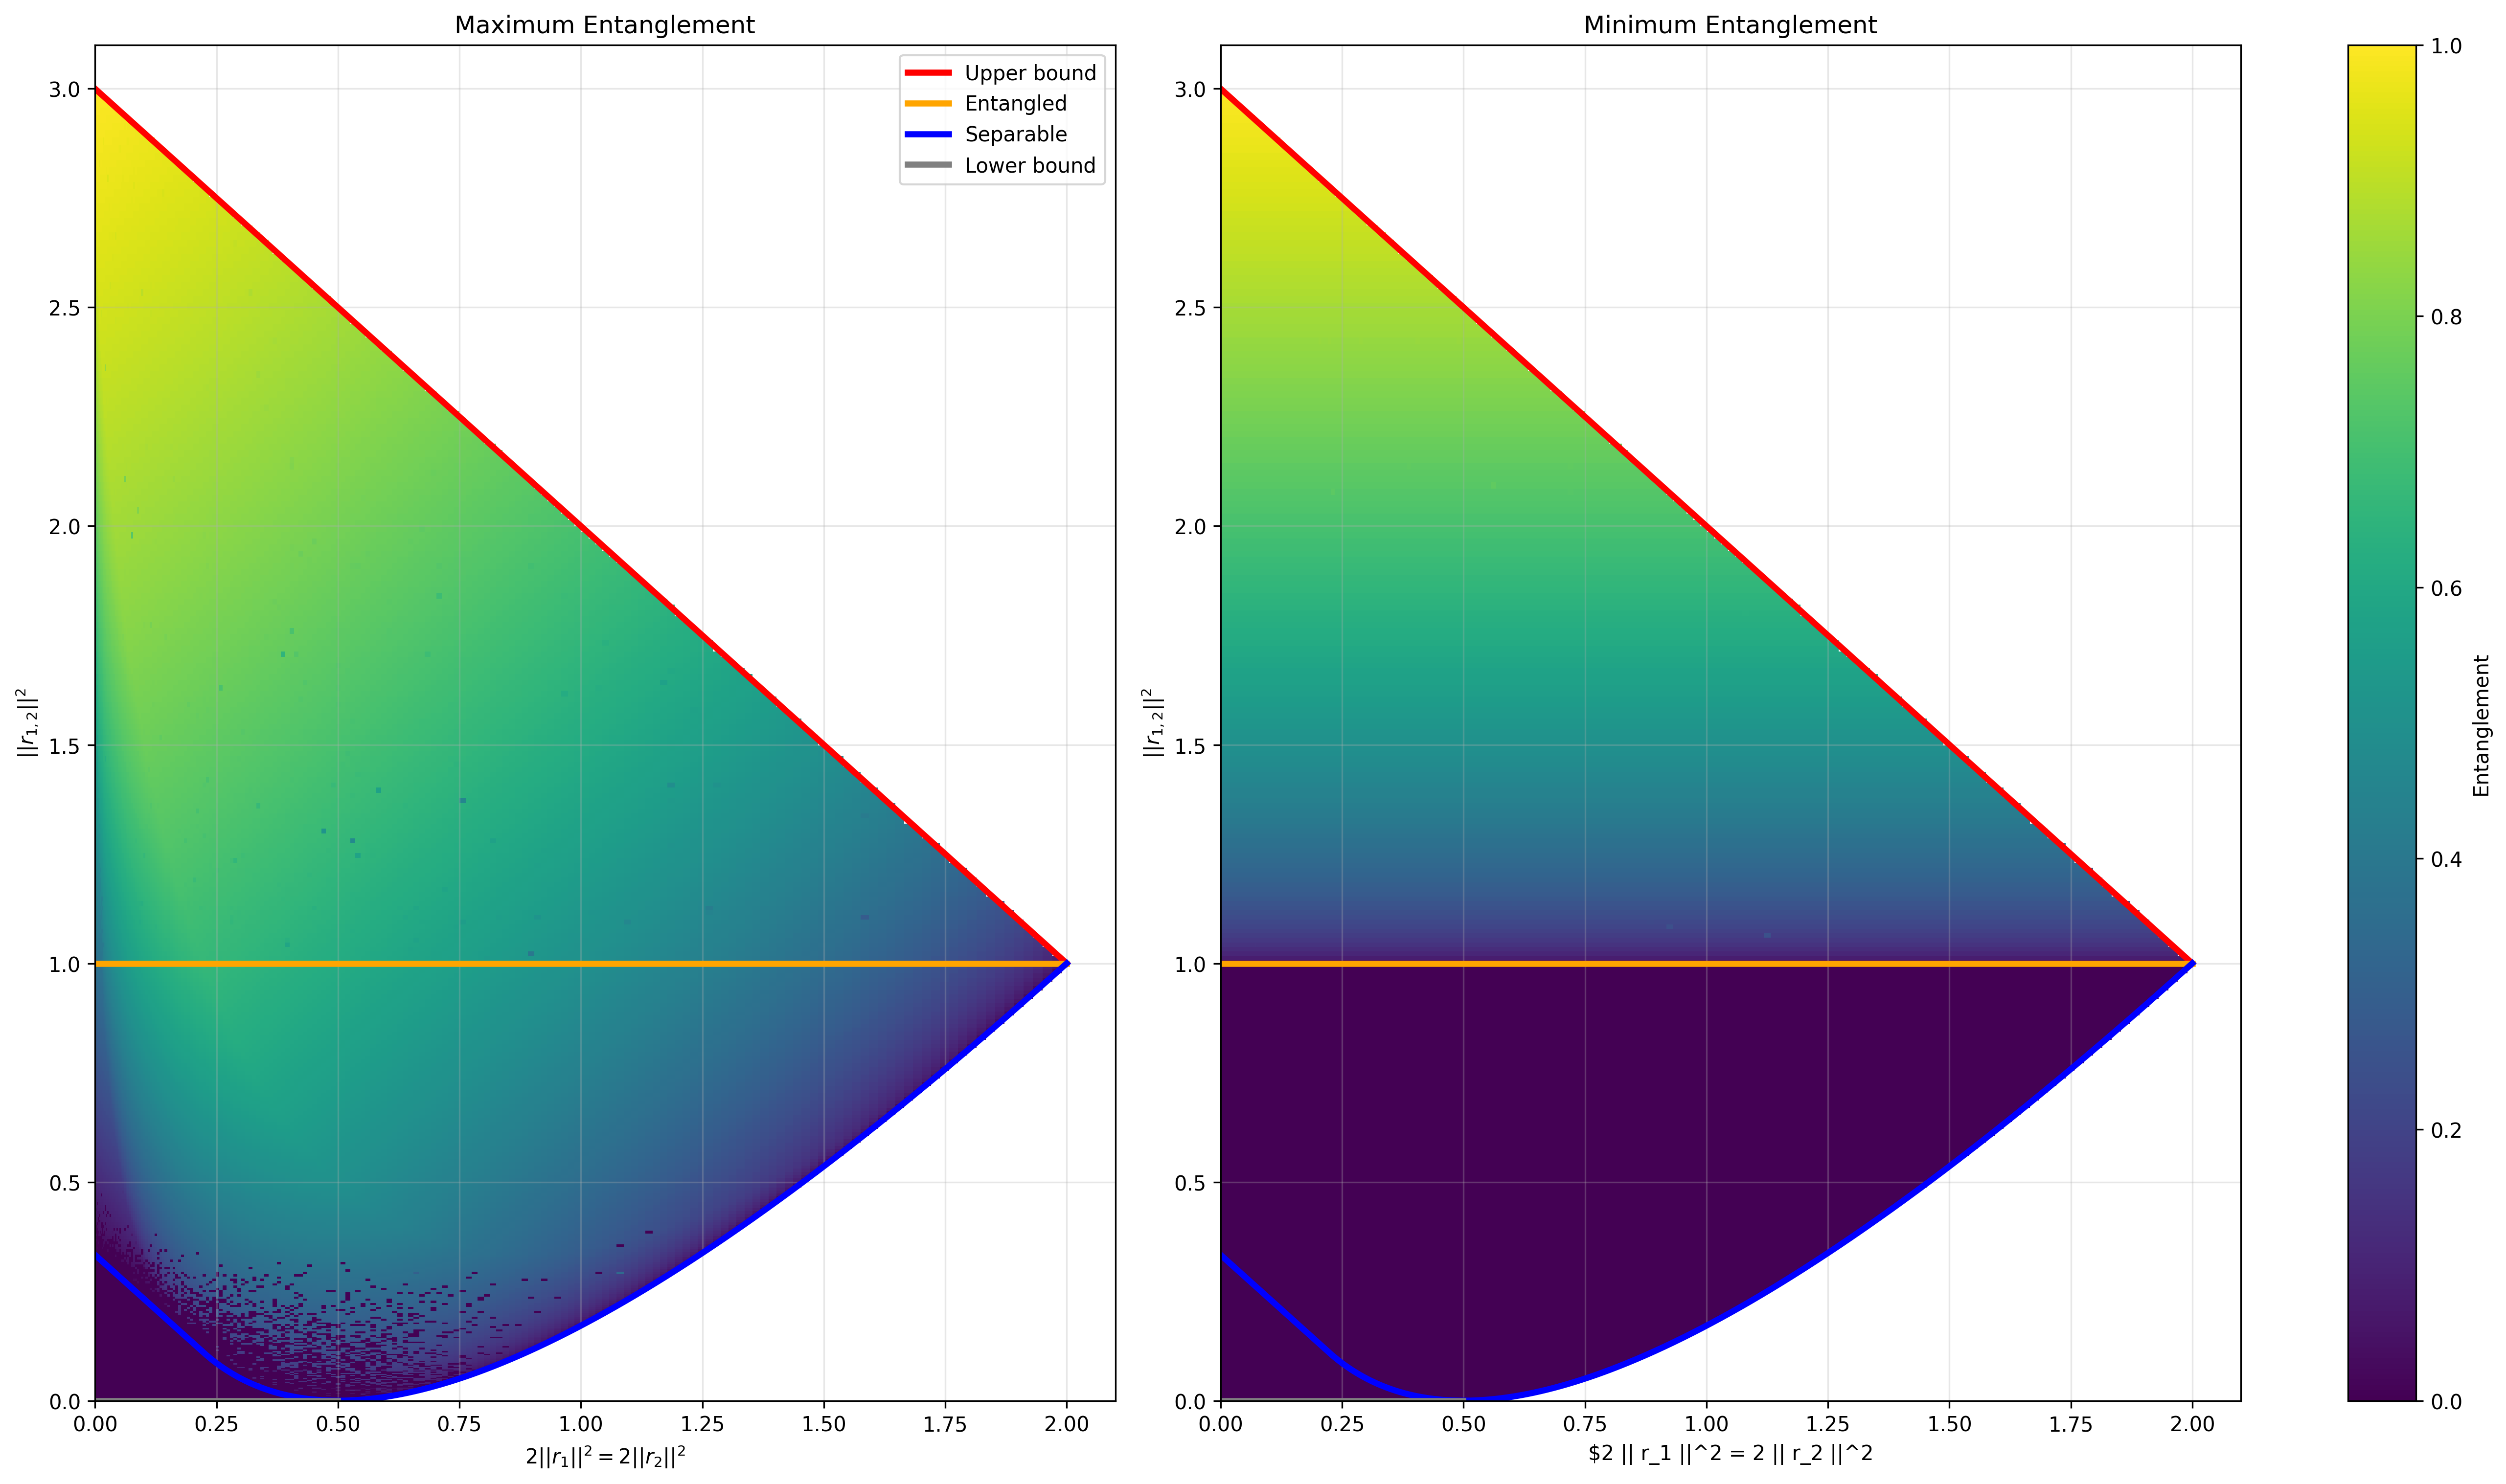

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(17, 10), constrained_layout=True, dpi=300)

mesh0 = ax[0].pcolormesh(2 * X**2, Z**2, ent_max, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh1 = ax[1].pcolormesh(2 * X**2, Z**2, ent_min, shading='auto', cmap='viridis', vmin=0, vmax=1)

cbar = fig.colorbar(mesh1, ax=ax.ravel().tolist(), label='Entanglement', 
                    pad=0.05, aspect=20, shrink=1)

cbar.set_ticks(list(np.linspace(0, 1, 6)))

ax[0].set(xlabel = r"$2 || r_1 ||^2 = 2 || r_2 ||^2$", ylabel = r"$||r_{1, 2}||^2$",
          xlim = (0, 2.1), ylim = (0, 3.1), title = "Maximum Entanglement")
ax[1].set(xlabel = r"$2 || r_1 ||^2 = 2 || r_2 ||^2", ylabel = r"$||r_{1, 2}||^2$",
          xlim = (0, 2.1), ylim = (0, 3.1), title = "Minimum Entanglement")

t = np.linspace(0, np.sqrt(2), 1000)
z_upper = np.sqrt(3 - t**2)
z_sep = np.piecewise(t, [t <= np.sqrt(2)/3, (t > np.sqrt(2)/3) & (t <= np.sqrt(2)/2), t > np.sqrt(2)/2],
                     [lambda t: np.sqrt(1/3 - t**2), lambda t: 1 - np.sqrt(2) * t, lambda t: np.sqrt(2) * t - 1])
z_ent = np.ones_like(t)
z_lower = np.where(t < np.sqrt(2)/2, 0, np.nan)

ax[0].plot(t**2, z_upper**2, 'red', linewidth=3, label='Upper bound')
ax[0].plot(t**2, z_ent**2, 'orange', linewidth=3, label='Entangled')
ax[0].plot(t**2, z_sep**2, 'blue', linewidth=3, label='Separable')
ax[0].plot(t**2, z_lower**2, 'grey', linewidth=3, label='Lower bound')

ax[1].plot(t**2, z_upper**2, 'red', linewidth=3, label='Upper bound')
ax[1].plot(t**2, z_ent**2, 'orange', linewidth=3, label='Entangled')
ax[1].plot(t**2, z_sep**2, 'blue', linewidth=3, label='Separable')
ax[1].plot(t**2, z_lower**2, 'grey', linewidth=3, label='Lower bound')

ax[0].legend(loc='upper right')
ax[0].grid(True, alpha=0.3)
ax[1].grid(True, alpha=0.3)

plt.show()